### Ingestão de Dados e Mapeamento de Classes

Em tarefas de segmentação semântica multiclasse, as máscaras originais são codificadas em cores visuais (RGB). Para que a função de perda da rede neural possa otimizar os pesos, precisamos converter essas matrizes de cores em **índices categóricos esparsos** (variando de 0 a $N-1$ classes). O dicionário abaixo estabelece a relação entre a assinatura visual do dataset de Dubai e o vetor de classes do modelo.

In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Mapeamento das imagens e máscaras
image_paths = sorted(glob.glob(os.path.join('data', 'Semantic segmentation dataset', '*', 'images', '*.jpg')))
mask_paths = sorted(glob.glob(os.path.join('data', 'Semantic segmentation dataset', '*', 'masks', '*.png')))

print(f"Total de Imagens: {len(image_paths)} | Total de Máscaras: {len(mask_paths)}")

# Dicionário de Cores (Dataset de Dubai)
# O formato das máscaras do Kaggle usa essas cores RGB para cada classe
COLOR_DICT = {
    'Building': [60, 16, 152],   # Prédios
    'Land': [132, 41, 246],      # Terra/Deserto
    'Road': [110, 193, 228],     # Estradas
    'Vegetation': [254, 221, 58],# Vegetação (A máscara é amarela no dataset original)
    'Water': [226, 169, 41],     # Água
    'Unlabeled': [155, 155, 155] # Sem rótulo
    #lembrete: essas configurações de cores deles pode estar atrapalhando a máquina, rever sobre essa configuração de coloração

}


# Convertendo para um array numpy para facilitar a busca
colors = np.array(list(COLOR_DICT.values()))
num_classes = len(colors)

c:\Users\renan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Total de Imagens: 72 | Total de Máscaras: 72


### Feature Engineering de Índices Espectrais

A essência do projeto reside na injeção de conhecimento de domínio na rede neural. Em vez de utilizar CPU e bibliotecas lentas para pré-processamento, as fórmulas do **ExG (Excess Green)** e **CIVE (Color Index of Vegetation)** foram reescritas como operações nativas de tensores (`tf.math`). 

Isso permite que:
1. O cálculo espectral seja paralelizado e acelerado pela GPU.
2. A matriz de entrada evolua de um espaço tridimensional `(R, G, B)` para um espaço pentadimensional `(R, G, B, ExG, CIVE)`, entregando o contraste da clorofila já isolado para a primeira camada convolucional.

In [2]:
# Dimensões da imagem para a U-Net
IMG_HEIGHT = 512 # mudar para 512 para treinamentos longos
IMG_WIDTH = 512

def processar_imagem_com_features(image_path):
    # Lê e decodifica a imagem RGB
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    
    # Normaliza para 0 a 1
    img_norm = tf.cast(img, tf.float32) / 255.0
    
    # Separa os canais para as fórmulas
    R = img_norm[:, :, 0]
    G = img_norm[:, :, 1]
    B = img_norm[:, :, 2]
    
    # Calcula ExG e CIVE usando tensores
    exg = 2.0 * G - R - B
    cive = 0.441 * R - 0.811 * G + 0.385 * B + 18.787
    
    # Expande as dimensões para poder empilhar
    exg = tf.expand_dims(exg, axis=-1)
    cive = tf.expand_dims(cive, axis=-1)
    
    # Empilha tudo, lembrando que a imagem agora tem 5 canais.
    img_5_channels = tf.concat([img_norm, exg, cive], axis=-1)
    
    return img_5_channels

def processar_mascara(mask_path):
    # Lê a máscara PNG colorida
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH], method='nearest')
    
    # Converte a máscara RGB em índices (0 a 5) usando o dicionário de cores
    mask = tf.cast(mask, tf.int32)
    distances = tf.reduce_sum(tf.abs(tf.expand_dims(mask, -2) - colors), axis=-1)
    mask_indices = tf.argmin(distances, axis=-1)
    mask_indices = tf.expand_dims(mask_indices, axis=-1)
    mask_indices = tf.cast(mask_indices, tf.int32)
    
    return mask_indices

def carregar_dados(image_path, mask_path):
    img = processar_imagem_com_features(image_path)
    mask = processar_mascara(mask_path)
    return img, mask

print("Funções de pré-processamento do TensorFlow criadas com sucesso!")

Funções de pré-processamento do TensorFlow criadas com sucesso!


### Pipeline e Augmentation

Para evitar gargalos de I/O durante o treinamento de imagens de alta resolução, construímos uma *pipeline* assíncrona utilizando `tf.data.Dataset`. 
* **Data Augmentation:** Implementado um espelhamento estocástico (50% de probabilidade) exclusivamente no conjunto de treino. Isso atua como uma forte regularização, mitigando o *overfitting* ao forçar a rede a aprender invariância rotacional.
* **Otimização:** Uso de `.cache()` e `.prefetch(AUTOTUNE)` para manter a GPU/CPU constantemente alimentada, reduzindo o tempo de inatividade entre as épocas.

In [ ]:
# Cria o dataset usando os caminhos dos arquivos
dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

# Aplica as funções de mapeamento (em paralelo com AUTOTUNE)
AUTOTUNE = tf.data.AUTOTUNE
dataset = dataset.map(carregar_dados, num_parallel_calls=AUTOTUNE)

# Separação do dataset 80% treino / 20% validação
DATASET_SIZE = len(image_paths)
train_size = int(0.8 * DATASET_SIZE)

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

def aumentar_dados(img, mask):
    # Espelha a imagem e a máscara horizontalmente (50% de chance)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    return img, mask

# Aplica o aumento no dataset de treino
train_dataset = train_dataset.map(aumentar_dados, num_parallel_calls=AUTOTUNE)

# Configura batches e cache para acelerar o treino
BATCH_SIZE = 4 # se consumir memória demais é bom reduzir para 2
train_dataset = train_dataset.cache().shuffle(100).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Pipeline tf.data configurada e pronta para alimentar a U-Net!")

Pipeline tf.data configurada e pronta para alimentar a U-Net!


### Arquitetura U-Net (Encoder-Decoder com Skip Connections)

A topologia escolhida para a segmentação de satélites é a U-Net. 
* O **Encoder** atua como um extrator de contexto, comprimindo a imagem multiespectral para entender *o quê* está na cena.
* O **Decoder** expande o mapa de características para recuperar a resolução espacial, entendendo *onde* os objetos estão.
* **Skip Connections:** Concatenações diretas que transferem os detalhes finos perdidos no *pooling* de volta para as camadas de saída.
* **Diferencial Crítico:** A `input_layer` foi explicitamente projetada para aceitar tensores de profundidade 5 (nossos índices calculados), divergindo do padrão da literatura (profundidade 3).

In [ ]:
from tensorflow.keras import layers, models

def construir_unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    #  ENCODER (Descendo o "U")
    # Bloco 1
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Bloco 2
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    #  BOTTLENECK (O fundo do "U") 
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # DECODER (Subindo o "U" com Skip Connections)
    # Bloco Expansão 1
    u4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2]) # Skip Connection do Bloco 2
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    # Bloco Expansão 2
    u5 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1]) # Skip Connection do Bloco 1
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    #  SAÍDA 
    # Uma camada convolucional final para mapear os pixels para as 6 classes
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Passamos 5 canais: R, G, B, ExG, CIVE
modelo_unet = construir_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 5), num_classes=num_classes)
modelo_unet.summary()

#todo: fazer comparações entre configurações de arquitetura

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,472 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 256, 256,  │     32,832 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 512, 512,  │      8,224 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512, 512,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 512, 512,  │     18,464 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 512, 512,  │      9,248 │ conv2d_8[0][0]  

 Total params: 467,270 (1.78 MB)

 Trainable params: 467,270 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

### Compilação, Callbacks e Treinamento

O modelo utiliza o otimizador Adam e a perda `sparse_categorical_crossentropy` (ideal para máscaras indexadas mutuamente excludentes).

Para garantir um treinamento longo e seguro em background, foi usado a estratégia de *Callbacks* que assume o controle do *Learning Rate*:
1. **ReduceLROnPlateau:** Reduz a taxa de aprendizado em 50% caso a perda de validação estagne, permitindo que o otimizador dê "passos menores" para sair de mínimos locais e refinar bordas críticas (como ruas estreitas).
2. **EarlyStopping:** Interrompe o treinamento preventivamente caso a generalização degrade, restaurando automaticamente a melhor matriz de pesos histórica.

Iniciando o treinamento
Epoch 1/150


15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.3984 - loss: 1.5887 - val_accuracy: 0.5933 - val_loss: 1.4866 - learning_rate: 0.0010
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.4085 - loss: 1.4125 - val_accuracy: 0.6062 - val_loss: 1.2862 - learning_rate: 0.0010
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.6206 - loss: 1.2406 - val_accuracy: 0.6287 - val_loss: 1.0686 - learning_rate: 0.0010
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.6525 - loss: 1.0486 - val_accuracy: 0.6279 - val_loss: 0.9789 - learning_rate: 0.0010
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6411 - loss: 1.0186 - val_accuracy: 0.6290 - val_loss: 0.9329 - learning_rate: 0.0010
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.6626 - loss: 0.9422 - val_accuracy: 0.6499 - val_loss: 0.8954 - learning_rate: 0.0010
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.6666 - loss: 0.9101 - val_accuracy: 0.680

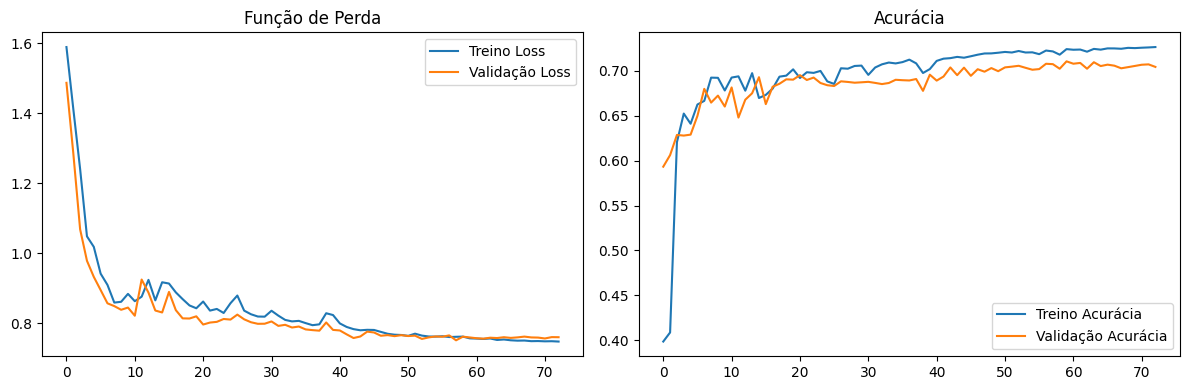

In [5]:
# Compilando o Modelo
modelo_unet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Iniciando o treinamento")

# Configurando Paradas Inteligentes (Early Stopping)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

# Reduce Learning Rate on Plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

history = modelo_unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=callbacks
)

# Gráfico de Evolução do Treinamento
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino Loss')
plt.plot(history.history['val_loss'], label='Validação Loss')
plt.title('Função de Perda')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treino Acurácia')
plt.plot(history.history['val_accuracy'], label='Validação Acurácia')
plt.title('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

### Predição vs. Rótulo humano

A acurácia global não é suficiente para validar modelos de segmentação semântica espacial. É bacana complementar com uma auditoria visual qualitativa no conjunto de validação (dados não vistos no treinamento).
Abaixo, extraímos um lote do `val_dataset` e realizamos a inferência. Comparamos lado a lado:
1. **Imagem RGB:** O dado ótico puro.
2. **Ground Truth:** A máscara anotada por humanos.
3. **Predição U-Net:** A saída indexada da rede convolucional. Isso permite inspecionar falhas morfológicas, como a difusão de bordas em vias estreitas (Roads).

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step


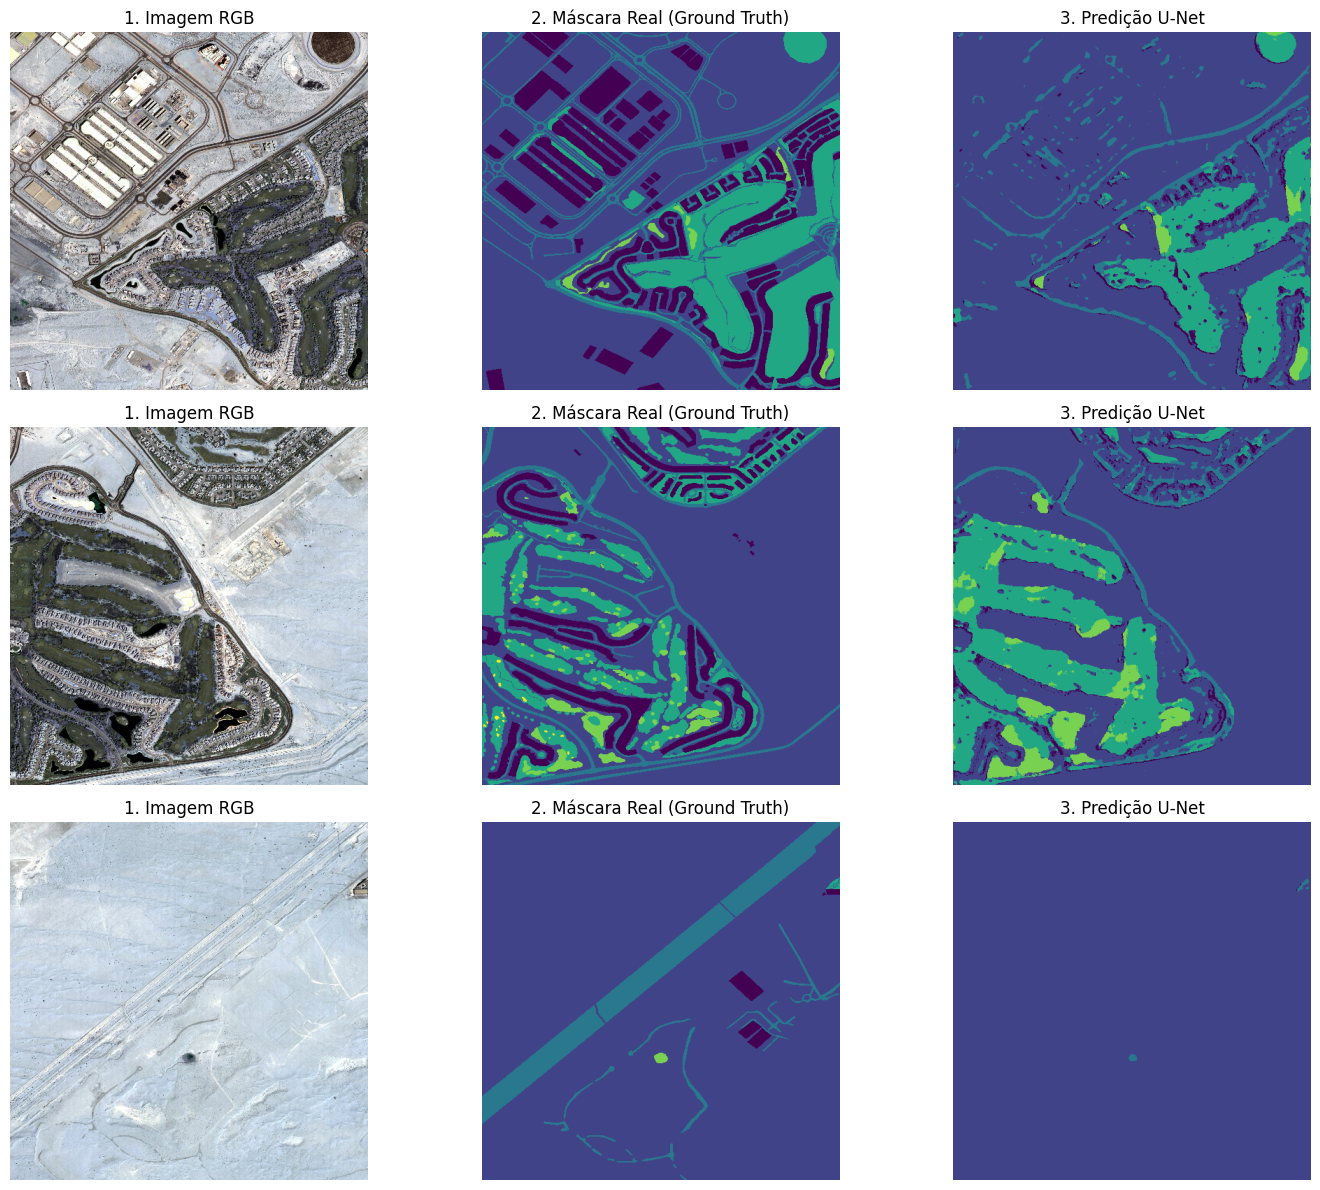

In [6]:
# Pega um lote de imagens e máscaras do conjunto de validação
for images, masks in val_dataset.take(1):
    # Fazer a predição e pegar a classe com maior probabilidade (argmax)
    preds = modelo_unet.predict(images)
    preds_classes = np.argmax(preds, axis=-1)
    
    # Plotar 3 exemplos lado a lado
    plt.figure(figsize=(15, 12))
    for i in range(3):
        # Imagem Original (Pegamos apenas os 3 primeiros canais RGB para visualização)
        plt.subplot(3, 3, i*3 + 1)
        plt.imshow(images[i][:,:,:3])
        plt.title("1. Imagem RGB", fontsize=12)
        plt.axis('off')
        
        # Ground Truth (Máscara Real)
        plt.subplot(3, 3, i*3 + 2)
        plt.imshow(masks[i], cmap='viridis', vmin=0, vmax=5)
        plt.title("2. Máscara Real (Ground Truth)", fontsize=12)
        plt.axis('off')
        
        # Predição do Modelo
        plt.subplot(3, 3, i*3 + 3)
        plt.imshow(preds_classes[i], cmap='viridis', vmin=0, vmax=5)
        plt.title("3. Predição U-Net", fontsize=12)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

### Matriz de Confusão

Para diagnosticar o comportamento do modelo diante do desbalanceamento de classes, o padrão ouro é a análise da Matriz de Confusão. 
Diferente de uma classificação de imagens simples (1 imagem = 1 classe), aqui nós **achatamos (flatten)** os tensores para avaliar a Inteligência Artificial a nível de pixel. Isso expõe claramente o erro intraclasse, revelando, por exemplo, se a rede está sofrendo confusão espectral entre 'Construções' e 'Estradas' devido à semelhança dos materiais (concreto/asfalto).

In [1]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true_all = []
y_pred_all = []

print("Extraindo e achatando pixels do conjunto de validação...")

# Pegamos 5 lotes de validação para ter uma amostragem estatística rica
for images, masks in val_dataset.take(5):
    preds = modelo_unet.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=-1)
    
    # Achata os tensores (de 256x256 para um array 1D longo)
    y_true_all.extend(tf.reshape(masks, [-1]).numpy())
    y_pred_all.extend(tf.reshape(preds_classes, [-1]).numpy())

# Calcula a Matriz de Confusão
cm = confusion_matrix(y_true_all, y_pred_all)

# Nomes das classes do nosso dicionário
class_names = list(COLOR_DICT.keys())

# Plota com Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão', fontsize=14)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Predita (U-Net)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Extraindo e achatando pixels do conjunto de validação...


NameError: name 'val_dataset' is not defined

In [8]:
# Salva a arquitetura e os pesos aprendidos
modelo_unet.save('modelo_unet.keras')
print("Modelo salvo para ser incorporado no Streamlit")

Modelo salvo para ser incorporado no Streamlit


## Conclusão e Próximos Passos

**Domínio Espectral:** O modelo comprovou a eficácia da injeção de *features* matemáticas no Deep Learning, onde ela foi capaz de segmentar macro-estruturas de vegetação e corpos hídricos de forma robusta, separando-os das manchas urbanas, mesmo com um número reduzido de épocas.
**Limitações de Resolução Física:** Devido ao *downsampling* necessário para a prototipagem local (redução da imagem para 512x512 pixels), micro-estruturas urbanas (como ruas de 10 metros de largura) sofrem "esmagamento" de pixels, gerando bordas difusas nas predições das máscaras.

**Próximos Passos:**
* **Sensoriamento Real em NIR:** Substituir os índices de espectro visível (ExG/CIVE) pelo cálculo real do **NDVI**, alimentando o modelo com a banda do Infravermelho Próximo (NIR) que um sensor de voo real captará.
* **Deploy Embarcado (Edge AI):** Quantizar os pesos do modelo treinado (via TensorFlow Lite) para avaliar o consumo de energia e a latência de inferência no hardware *Edge* (OBC) do nanossatélite antes de implementar o aplicativo via Streamlit na estação solo.